# Image Segmentation-II Lab - Lecture 10
# Digital Image Processing


Lab Overview:
1. Semantic Segmentation with DeepLabV3
2. Instance Segmentation with Mask R-CNN
3. Real-time Segmentation with YOLOv8
4. Video Segmentation
5. Fine-tuning a Segmentation Model

# SECTION 1: Setup and Installations

In [ ]:
# Install required packages
# Run these in terminal or uncomment:
# pip install torch torchvision
# pip install ultralytics
# pip install opencv-python
# pip install pillow
# pip install matplotlib
# pip install numpy

In [5]:
import torch
import torchvision
from torchvision import transforms
from torchvision.models.segmentation import deeplabv3_resnet101, fcn_resnet50
from torchvision.models.detection import maskrcnn_resnet50_fpn_v2
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from ultralytics import YOLO
import os
from pathlib import Path

In [2]:
import torch
import torchvision
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)


Torch: 1.13.1+cu116
Torchvision: 0.14.1+cu116
OpenCV: 4.11.0
NumPy: 1.26.4


In [3]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


In [4]:
import torch
print(torch.cuda.is_available())  # Should print True
print(torch.cuda.get_device_name(0))  # Should print your GPU name


True
NVIDIA GeForce RTX 3080 Laptop GPU


# SECTION 2: Utility Functions

In [6]:
def display_images(images, titles, figsize=(15, 5), cmap=None):
    """Display multiple images side by side"""
    fig, axes = plt.subplots(1, len(images), figsize=figsize)
    if len(images) == 1:
        axes = [axes]
    
    for ax, img, title in zip(axes, images, titles):
        if isinstance(img, torch.Tensor):
            img = img.permute(1, 2, 0).cpu().numpy()
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

def load_image(image_path, size=(512, 512)):
    """Load and preprocess image"""
    image = Image.open(image_path).convert('RGB')
    image = image.resize(size)
    return image

def create_color_map(num_classes=21):
    """Create color map for semantic segmentation visualization"""
    np.random.seed(42)
    colors = np.random.randint(0, 255, size=(num_classes, 3), dtype=np.uint8)
    colors[0] = [0, 0, 0]  # Background as black
    return colors

# SECTION 3: Semantic Segmentation with DeepLabV3


Loading DeepLabV3 model...


c:\Users\muhamsaj\anaconda3\envs\workenv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\muhamsaj\anaconda3\envs\workenv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to C:\Users\muhamsaj/.cache\torch\hub\checkpoints\deeplabv3_resnet101_coco-586e9e4e.pth


  0%|          | 0.00/233M [00:00<?, ?B/s]

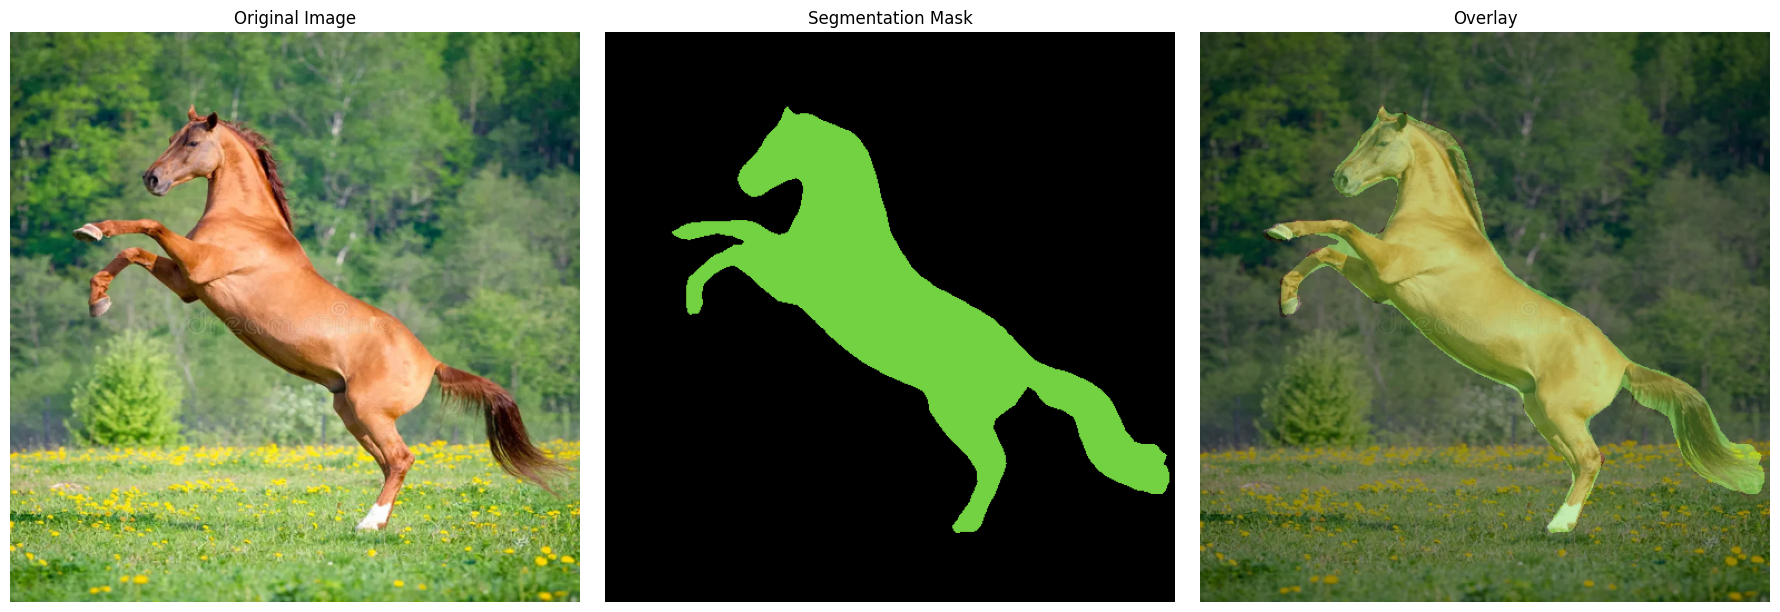

DeepLabV3 semantic segmentation ready!
Key Features:
  - Atrous convolutions for larger receptive field
  - ASPP module for multi-scale context
  - 21 classes from Pascal VOC dataset


In [7]:
# Load pretrained DeepLabV3 model
print("\nLoading DeepLabV3 model...")
deeplabv3_model = deeplabv3_resnet101(pretrained=True)
deeplabv3_model = deeplabv3_model.to(device)
deeplabv3_model.eval()

# Pascal VOC classes
PASCAL_VOC_CLASSES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

def semantic_segmentation_deeplabv3(image_path):
    """Perform semantic segmentation using DeepLabV3"""
    # Load and preprocess image
    image = load_image(image_path)
    
    # Transform for model
    preprocess = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                           std=[0.229, 0.224, 0.225])
    ])
    
    input_tensor = preprocess(image).unsqueeze(0).to(device)
    
    # Inference
    with torch.no_grad():
        output = deeplabv3_model(input_tensor)['out'][0]
    
    # Get segmentation mask
    output_predictions = output.argmax(0).byte().cpu().numpy()
    
    # Create colored mask
    color_map = create_color_map(21)
    colored_mask = color_map[output_predictions]
    
    # Overlay on original image
    image_np = np.array(image)
    overlay = cv2.addWeighted(image_np, 0.6, colored_mask, 0.4, 0)
    
    return image, output_predictions, colored_mask, overlay

# Example usage (you need to provide an image)
# Uncomment and provide your image path:

image_path = 'image1.png'
original, mask, colored_mask, overlay = semantic_segmentation_deeplabv3(image_path)
display_images(
    [original, colored_mask, overlay],
    ['Original Image', 'Segmentation Mask', 'Overlay'],
    figsize=(18, 6)
)


print("DeepLabV3 semantic segmentation ready!")
print("Key Features:")
print("  - Atrous convolutions for larger receptive field")
print("  - ASPP module for multi-scale context")
print("  - 21 classes from Pascal VOC dataset")

# SECTION 4: Instance Segmentation with Mask R-CNN


Loading Mask R-CNN model...


c:\Users\muhamsaj\anaconda3\envs\workenv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_V2_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_v2_coco-73cbd019.pth" to C:\Users\muhamsaj/.cache\torch\hub\checkpoints\maskrcnn_resnet50_fpn_v2_coco-73cbd019.pth


  0%|          | 0.00/177M [00:00<?, ?B/s]

Detected 7 instances


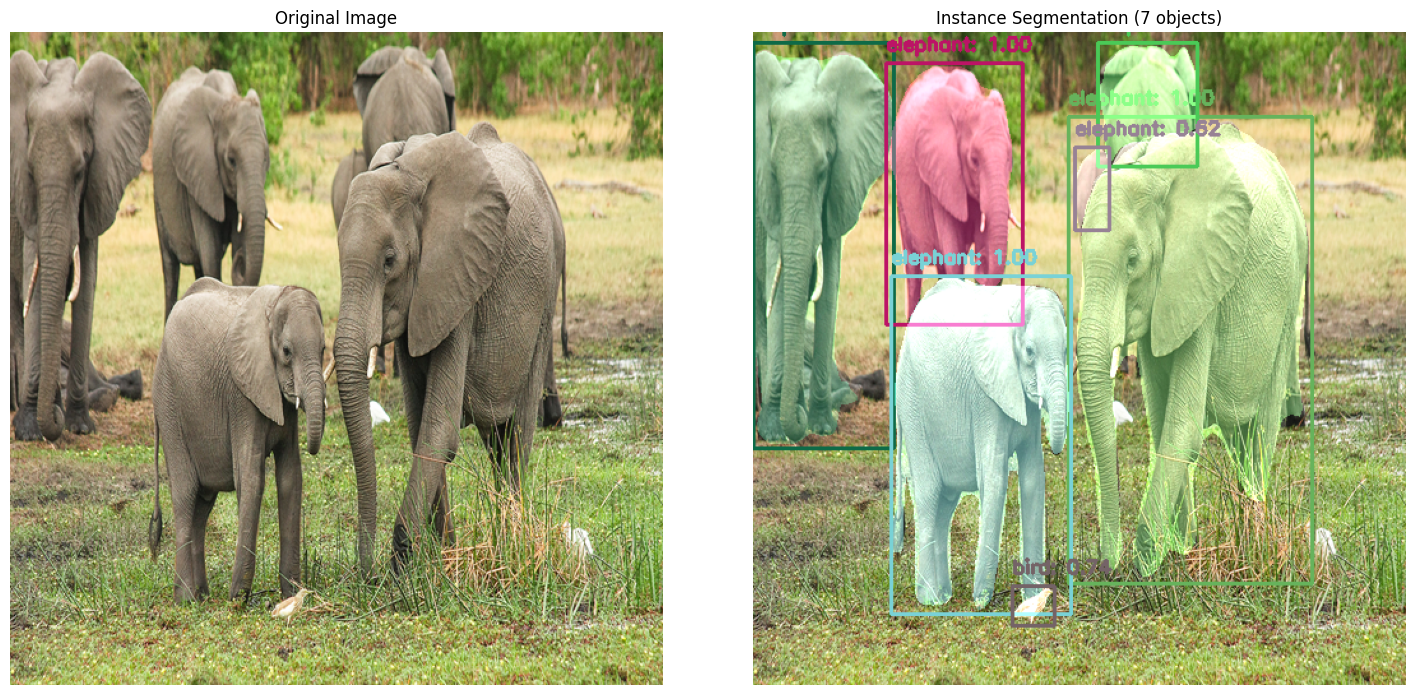

Mask R-CNN instance segmentation ready!
Key Features:
  - Two-stage detector (RPN + heads)
  - RoI Align for precise mask alignment
  - 80 COCO categories
  - Separate masks for each instance


In [8]:
# Load pretrained Mask R-CNN model
print("\nLoading Mask R-CNN model...")
maskrcnn_model = maskrcnn_resnet50_fpn_v2(pretrained=True)
maskrcnn_model = maskrcnn_model.to(device)
maskrcnn_model.eval()

# COCO classes
COCO_CLASSES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
    'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table',
    'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 
    'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book',
    'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

def instance_segmentation_maskrcnn(image_path, threshold=0.5):
    """Perform instance segmentation using Mask R-CNN"""
    # Load image
    image = load_image(image_path)
    
    # Transform
    transform = transforms.Compose([transforms.ToTensor()])
    input_tensor = transform(image).to(device)
    
    # Inference
    with torch.no_grad():
        predictions = maskrcnn_model([input_tensor])[0]
    
    # Filter predictions by threshold
    scores = predictions['scores'].cpu().numpy()
    keep = scores > threshold
    
    boxes = predictions['boxes'][keep].cpu().numpy()
    labels = predictions['labels'][keep].cpu().numpy()
    masks = predictions['masks'][keep].cpu().numpy()
    scores = scores[keep]
    
    # Visualize results
    image_np = np.array(image)
    result_image = image_np.copy()
    
    # Generate random colors for instances
    np.random.seed(42)
    colors = np.random.randint(0, 255, size=(len(masks), 3))
    
    # Draw masks and boxes
    for i, (box, label, mask, score, color) in enumerate(zip(boxes, labels, masks, scores, colors)):
        # Apply mask
        mask = mask[0] > 0.5
        colored_mask = np.zeros_like(result_image)
        colored_mask[mask] = color
        result_image = cv2.addWeighted(result_image, 1, colored_mask, 0.5, 0)
        
        # Draw box
        x1, y1, x2, y2 = box.astype(int)
        cv2.rectangle(result_image, (x1, y1), (x2, y2), color.tolist(), 2)
        
        # Add label
        label_text = f"{COCO_CLASSES[label]}: {score:.2f}"
        cv2.putText(result_image, label_text, (x1, y1-10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, color.tolist(), 2)
    
    return image, result_image, len(masks)

# Example usage:

image_path = 'image2.png'
original, segmented, num_instances = instance_segmentation_maskrcnn(image_path)
print(f"Detected {num_instances} instances")
display_images(
    [original, segmented],
    ['Original Image', f'Instance Segmentation ({num_instances} objects)'],
    figsize=(15, 7)
)


print("Mask R-CNN instance segmentation ready!")
print("Key Features:")
print("  - Two-stage detector (RPN + heads)")
print("  - RoI Align for precise mask alignment")
print("  - 80 COCO categories")
print("  - Separate masks for each instance")

# SECTION 5: Real-time Segmentation with YOLOv8


Loading YOLOv8 segmentation model...

image 1/1 e:\DIP COURSE\Fall 2025\Week 10\Week 10\Week 10\Week 10\image3.png: 352x640 10 persons, 5 bicycles, 4 cars, 1 bus, 219.3ms
Speed: 3.7ms preprocess, 219.3ms inference, 5.2ms postprocess per image at shape (1, 3, 352, 640)


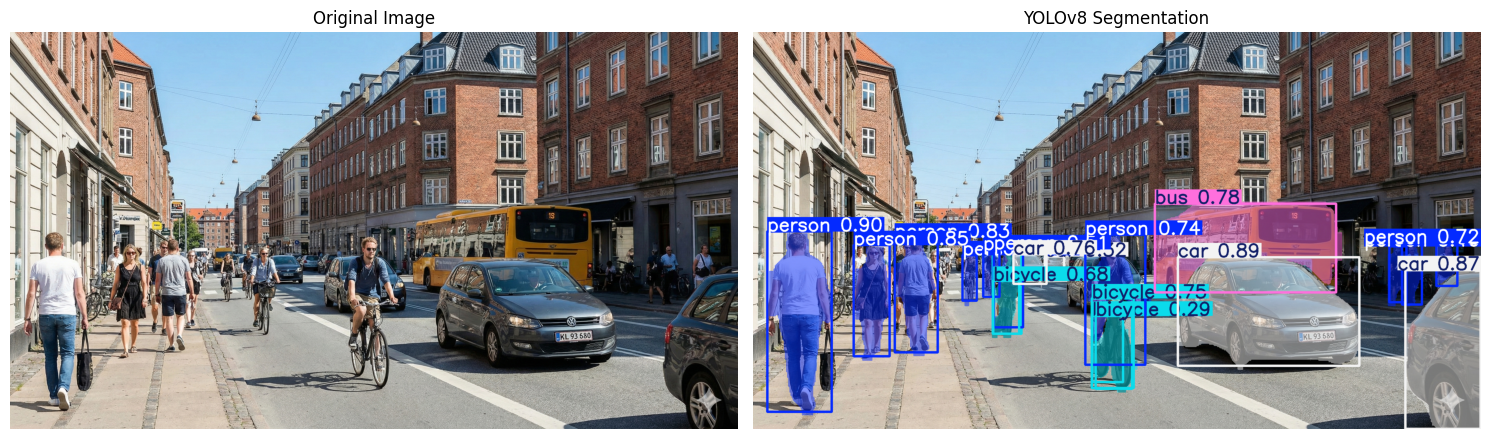


Detected objects:
  - person: 0.90
  - car: 0.89
  - car: 0.87
  - person: 0.85
  - person: 0.83
  - bus: 0.78
  - car: 0.76
  - bicycle: 0.75
  - person: 0.74
  - person: 0.72
  - bicycle: 0.68
  - person: 0.68
  - person: 0.51
  - person: 0.46
  - person: 0.45
  - person: 0.36
  - car: 0.32
  - bicycle: 0.29
  - bicycle: 0.26
  - bicycle: 0.26
YOLOv8 segmentation ready!
Key Features:
  - Single-stage detector (very fast)
  - 30-60 FPS on GPU
  - Anchor-free detection
  - Ideal for real-time applications


In [9]:
# Load YOLOv8 segmentation model
print("\nLoading YOLOv8 segmentation model...")
yolo_model = YOLO('yolov8n-seg.pt')  # nano version for speed

def yolo_segmentation(image_path, conf_threshold=0.25):
    """Perform segmentation using YOLOv8"""
    # Load image
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Inference
    results = yolo_model(image_path, conf=conf_threshold)[0]
    
    # Visualize
    result_image = results.plot()
    result_image = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB)
    
    return image_rgb, result_image, results

# Example usage:

image_path = 'image3.png'
original, segmented, results = yolo_segmentation(image_path)
display_images(
    [original, segmented],
    ['Original Image', 'YOLOv8 Segmentation'],
    figsize=(15, 7)
)

# Print detection details
print(f"\nDetected objects:")
for box in results.boxes:
    class_id = int(box.cls[0])
    conf = float(box.conf[0])
    class_name = results.names[class_id]
    print(f"  - {class_name}: {conf:.2f}")

print("YOLOv8 segmentation ready!")
print("Key Features:")
print("  - Single-stage detector (very fast)")
print("  - 30-60 FPS on GPU")
print("  - Anchor-free detection")
print("  - Ideal for real-time applications")



# SECTION 6: Video Segmentation with YOLO

In [10]:
def video_segmentation_yolo(video_path, output_path='output_video.mp4', conf_threshold=0.25):
    """Perform segmentation on video using YOLOv8"""
    # Open video
    cap = cv2.VideoCapture(video_path)
    
    # Get video properties
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Create video writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    
    print(f"\nProcessing video: {total_frames} frames at {fps} FPS")
    print(f"Resolution: {width}x{height}")
    
    frame_count = 0
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        
        # Perform segmentation
        results = yolo_model(frame, conf=conf_threshold, verbose=False)[0]
        
        # Draw results on frame
        annotated_frame = results.plot()
        
        # Write frame
        out.write(annotated_frame)
        
        frame_count += 1
        if frame_count % 30 == 0:
            print(f"Processed {frame_count}/{total_frames} frames")
    
    # Release resources
    cap.release()
    out.release()
    
    print(f"\nVideo saved to: {output_path}")
    return output_path

# Example usage:
video_path = 'vtest.mp4'
output_path = video_segmentation_yolo(video_path, 'segmented_video.mp4')
print(f"Segmented video saved!")

print("Video segmentation ready!")
print("Features:")
print("  - Processes videos frame by frame")
print("  - Maintains original FPS and resolution")
print("  - Can process webcam feed in real-time")


Processing video: 795 frames at 10 FPS
Resolution: 640x480
Processed 30/795 frames
Processed 60/795 frames
Processed 90/795 frames
Processed 120/795 frames
Processed 150/795 frames
Processed 180/795 frames
Processed 210/795 frames
Processed 240/795 frames
Processed 270/795 frames
Processed 300/795 frames
Processed 330/795 frames
Processed 360/795 frames
Processed 390/795 frames
Processed 420/795 frames
Processed 450/795 frames
Processed 480/795 frames
Processed 510/795 frames
Processed 540/795 frames
Processed 570/795 frames
Processed 600/795 frames
Processed 630/795 frames
Processed 660/795 frames
Processed 690/795 frames
Processed 720/795 frames
Processed 750/795 frames
Processed 780/795 frames

Video saved to: segmented_video.mp4
Segmented video saved!
Video segmentation ready!
Features:
  - Processes videos frame by frame
  - Maintains original FPS and resolution
  - Can process webcam feed in real-time


In [12]:
# Alternative: Real-time webcam segmentation
def webcam_segmentation(conf_threshold=0.25, max_frames=100):
    """Real-time segmentation from webcam"""
    cap = cv2.VideoCapture(0)
    
    frame_count = 0
    print("\nStarting webcam... Press 'q' to quit")
    
    while frame_count < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        # Perform segmentation
        results = yolo_model(frame, conf=conf_threshold, verbose=False)[0]
        annotated_frame = results.plot()
        
        # Display
        cv2.imshow('YOLOv8 Segmentation', annotated_frame)
        
        # Press 'q' to quit
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
        
        frame_count += 1
    
    cap.release()
    cv2.destroyAllWindows()

# Uncomment to run:
webcam_segmentation()


Starting webcam... Press 'q' to quit


# SECTION 7: Fine-tuning a Segmentation Model

In [13]:
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.models.segmentation import fcn_resnet50
import torch.nn as nn
import torch.optim as optim

class SimpleSegmentationDataset(Dataset):
    """
    Simple segmentation dataset class
    
    Expected structure:
    dataset/
        images/
            img1.jpg
            img2.jpg
        masks/
            img1.png
            img2.png
    """
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.transform = transform
        self.images = sorted(list(self.image_dir.glob('*.jpg')) + 
                           list(self.image_dir.glob('*.png')))
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        # Load image
        img_path = self.images[idx]
        image = Image.open(img_path).convert('RGB')
        
        # Load mask
        mask_path = self.mask_dir / img_path.name.replace('.jpg', '.png')
        mask = Image.open(mask_path).convert('L')
        
        # Resize mask to match the image size ---
        # We use NEAREST to preserve exact class values (0, 1, 2...)
        mask = mask.resize((256, 256), resample=Image.NEAREST)
        
        if self.transform:
            # This applies the resize/normalize to the IMAGE
            image = self.transform(image)
            
            # Convert mask to tensor manually
            mask = transforms.ToTensor()(mask)
            # Scale back to 0-255 integers (since ToTensor makes it 0-1)
            mask = (mask * 255).long().squeeze(0)
        
        return image, mask

def train_segmentation_model(train_loader, num_classes=2, epochs=1):
    """
    Fine-tune FCN model on custom dataset
    
    Args:
        train_loader: DataLoader with training data
        num_classes: Number of classes (including background)
        epochs: Number of training epochs
    """
    # Load pretrained model
    model = fcn_resnet50(pretrained=True)
    
    # Modify classifier for custom number of classes
    model.classifier[4] = nn.Conv2d(512, num_classes, kernel_size=1)
    model.aux_classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)
    
    model = model.to(device)
    
    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    
    print(f"\nStarting training for {epochs} epoch(s)...")
    print(f"Number of classes: {num_classes}")
    print(f"Device: {device}")
    
    model.train()
    
    for epoch in range(epochs):
        running_loss = 0.0
        
        for batch_idx, (images, masks) in enumerate(train_loader):
            images = images.to(device)
            masks = masks.to(device)
            
            # Forward pass
            optimizer.zero_grad()
            outputs = model(images)['out']
            
            # Calculate loss
            loss = criterion(outputs, masks)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
            if (batch_idx + 1) % 5 == 0:
                print(f"Epoch [{epoch+1}/{epochs}], "
                      f"Batch [{batch_idx+1}/{len(train_loader)}], "
                      f"Loss: {loss.item():.4f}")
        
        avg_loss = running_loss / len(train_loader)
        print(f"\nEpoch [{epoch+1}/{epochs}] completed. Average Loss: {avg_loss:.4f}")
    
    print("\nTraining completed!")
    return model

# Example fine-tuning workflow:


# Step 1: Create dataset and dataloader
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

train_dataset = SimpleSegmentationDataset(
    'Semantic Seg Dataset/train/images',
    'Semantic Seg Dataset/train/masks',
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

# Step 2: Fine-tune model
# We have two classes: background and road
trained_model = train_segmentation_model(train_loader, num_classes=2, epochs=1)

# Step 3: Save model
torch.save(trained_model.state_dict(), 'finetuned_segmentation_model.pth')
print("Model saved!")


print("\nFine-tuning setup ready!")
print("To fine-tune:")
print("  1. Prepare your dataset (images + masks)")
print("  2. Create DataLoader")
print("  3. Run train_segmentation_model()")
print("  4. Save the trained model")

c:\Users\muhamsaj\anaconda3\envs\workenv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FCN_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=FCN_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/fcn_resnet50_coco-1167a1af.pth" to C:\Users\muhamsaj/.cache\torch\hub\checkpoints\fcn_resnet50_coco-1167a1af.pth


  0%|          | 0.00/135M [00:00<?, ?B/s]


Starting training for 1 epoch(s)...
Number of classes: 2
Device: cuda
Epoch [1/1], Batch [5/46], Loss: 0.1554
Epoch [1/1], Batch [10/46], Loss: 0.1064
Epoch [1/1], Batch [15/46], Loss: 0.1019
Epoch [1/1], Batch [20/46], Loss: 0.1054
Epoch [1/1], Batch [25/46], Loss: 0.0717
Epoch [1/1], Batch [30/46], Loss: 0.0710
Epoch [1/1], Batch [35/46], Loss: 0.0748
Epoch [1/1], Batch [40/46], Loss: 0.0595
Epoch [1/1], Batch [45/46], Loss: 0.0636

Epoch [1/1] completed. Average Loss: 0.1160

Training completed!
Model saved!

Fine-tuning setup ready!
To fine-tune:
  1. Prepare your dataset (images + masks)
  2. Create DataLoader
  3. Run train_segmentation_model()
  4. Save the trained model


In [14]:
def inference_finetuned_model(model, image_path, num_classes=2, visualize=True):
    """
    Perform inference using the fine-tuned model
    
    Args:
        model: Trained segmentation model
        image_path: Path to input image
        num_classes: Number of classes
        visualize: Whether to return visualization
    
    Returns:
        original_image, predicted_mask, colored_mask (if visualize=True)
    """
    model.eval()
    
    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')
    original_size = image.size
    
    # Transform for model
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                           std=[0.229, 0.224, 0.225])
    ])
    
    input_tensor = transform(image).unsqueeze(0).to(device)
    
    # Inference
    with torch.no_grad():
        output = model(input_tensor)['out']
        prediction = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()
    
    # Resize prediction back to original size
    prediction = cv2.resize(prediction.astype(np.uint8), original_size, 
                           interpolation=cv2.INTER_NEAREST)
    
    if visualize:
        # Create colored mask
        color_map = create_color_map(num_classes)
        colored_mask = color_map[prediction]
        
        # Create overlay
        image_np = np.array(image)
        overlay = cv2.addWeighted(image_np, 0.6, colored_mask, 0.4, 0)
        
        return image, prediction, colored_mask, overlay
    
    return prediction

def test_finetuned_model(model, test_dir, num_samples=5, num_classes=2):
    """
    Test the fine-tuned model on multiple images from test directory
    
    Args:
        model: Trained segmentation model
        test_dir: Directory containing test images
        num_samples: Number of images to visualize
        num_classes: Number of classes in the model
    """
    # Get all images from test directory
    test_dir = Path(test_dir)
    image_files = list(test_dir.glob('*.jpg')) + list(test_dir.glob('*.png'))
    
    if len(image_files) == 0:
        print(f"No images found in {test_dir}")
        return
    
    # Limit to num_samples
    image_files = image_files[:num_samples]
    
    print(f"\nTesting fine-tuned model on {len(image_files)} images...")
    print("="*60)
    
    # Process each image
    for idx, img_path in enumerate(image_files):
        print(f"\nProcessing image {idx+1}/{len(image_files)}: {img_path.name}")
        
        # Run inference
        original, pred_mask, colored_mask, overlay = inference_finetuned_model(
            model, str(img_path), num_classes=num_classes
        )
        
        # Display results
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        
        axes[0].imshow(original)
        axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
        axes[0].axis('off')
        
        axes[1].imshow(pred_mask, cmap='tab20')
        axes[1].set_title('Predicted Mask', fontsize=12, fontweight='bold')
        axes[1].axis('off')
        
        axes[2].imshow(colored_mask)
        axes[2].set_title('Colored Mask', fontsize=12, fontweight='bold')
        axes[2].axis('off')
        
        axes[3].imshow(overlay)
        axes[3].set_title('Overlay', fontsize=12, fontweight='bold')
        axes[3].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Print prediction statistics
        unique_classes = np.unique(pred_mask)
        print(f"  Detected classes: {unique_classes}")
        for cls in unique_classes:
            pixels = np.sum(pred_mask == cls)
            percentage = (pixels / pred_mask.size) * 100
            print(f"    Class {cls}: {pixels} pixels ({percentage:.2f}%)")


Step 5: Testing fine-tuned model on test images...

Testing fine-tuned model on 5 images...

Processing image 1/5: pic103-0_jpg.rf.74a44720496ac2ca64502823ea388be2.jpg


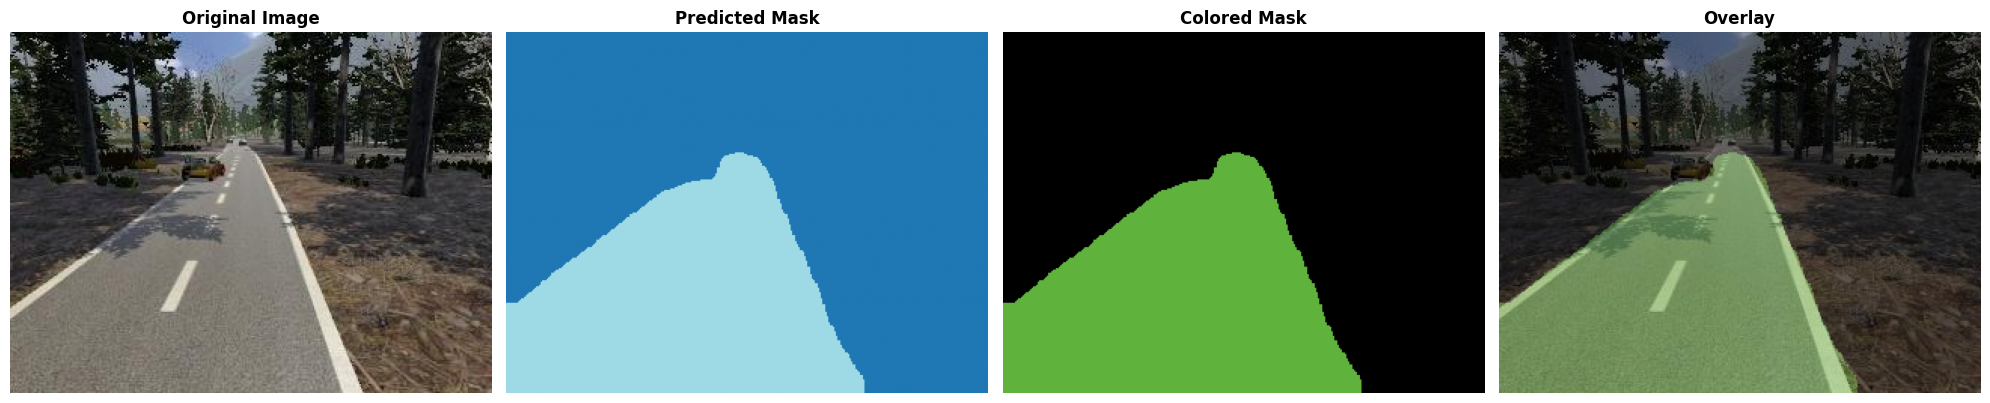

  Detected classes: [0 1]
    Class 0: 51944 pixels (67.64%)
    Class 1: 24856 pixels (32.36%)

Processing image 2/5: pic115-0_jpg.rf.a3c049a6bbf8ba806d07d47aea28cc7b.jpg


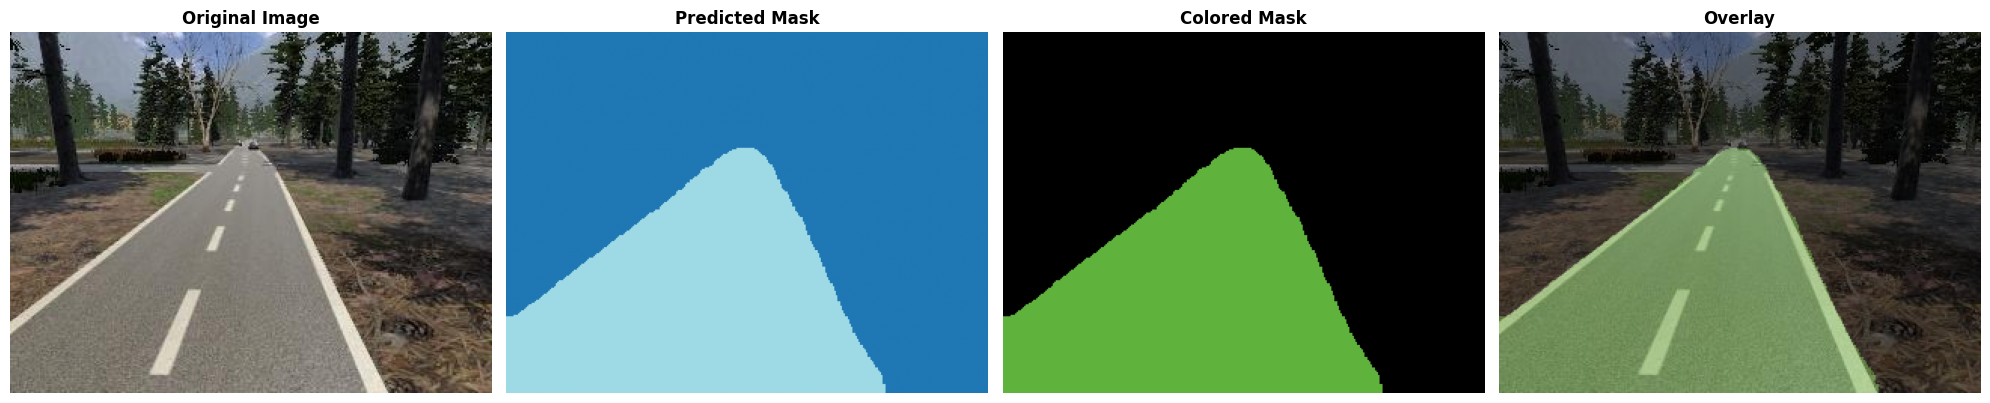

  Detected classes: [0 1]
    Class 0: 51095 pixels (66.53%)
    Class 1: 25705 pixels (33.47%)

Processing image 3/5: pic130-0_jpg.rf.f5cdf8abecb341322e765327b841d68f.jpg


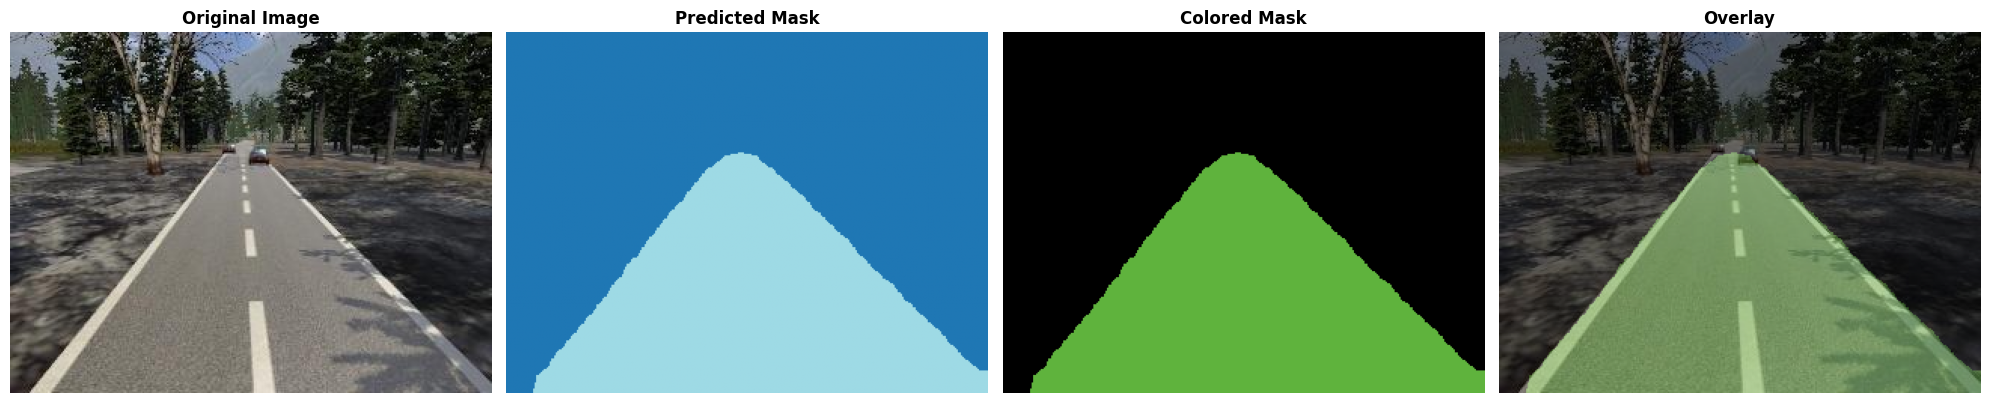

  Detected classes: [0 1]
    Class 0: 49677 pixels (64.68%)
    Class 1: 27123 pixels (35.32%)

Processing image 4/5: pic132-0_jpg.rf.ca8da323ccb6eebc97820145b7268a00.jpg


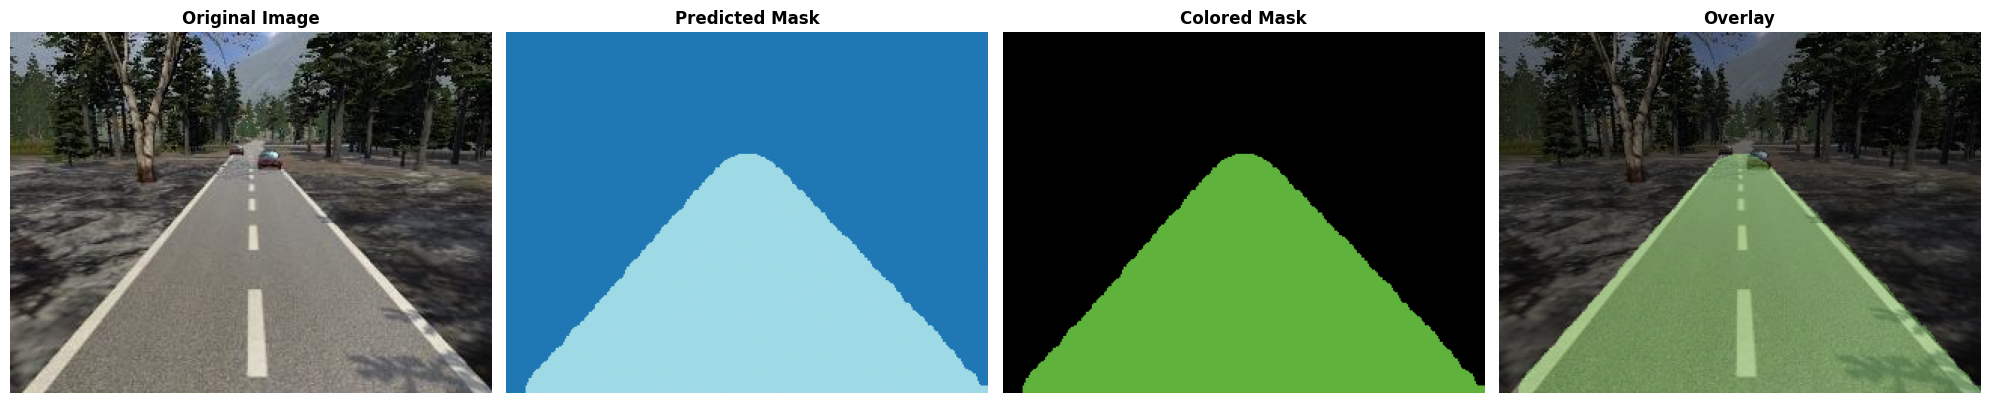

  Detected classes: [0 1]
    Class 0: 49765 pixels (64.80%)
    Class 1: 27035 pixels (35.20%)

Processing image 5/5: pic144-0_jpg.rf.a283921920f19b32d447cbab0f58ac88.jpg


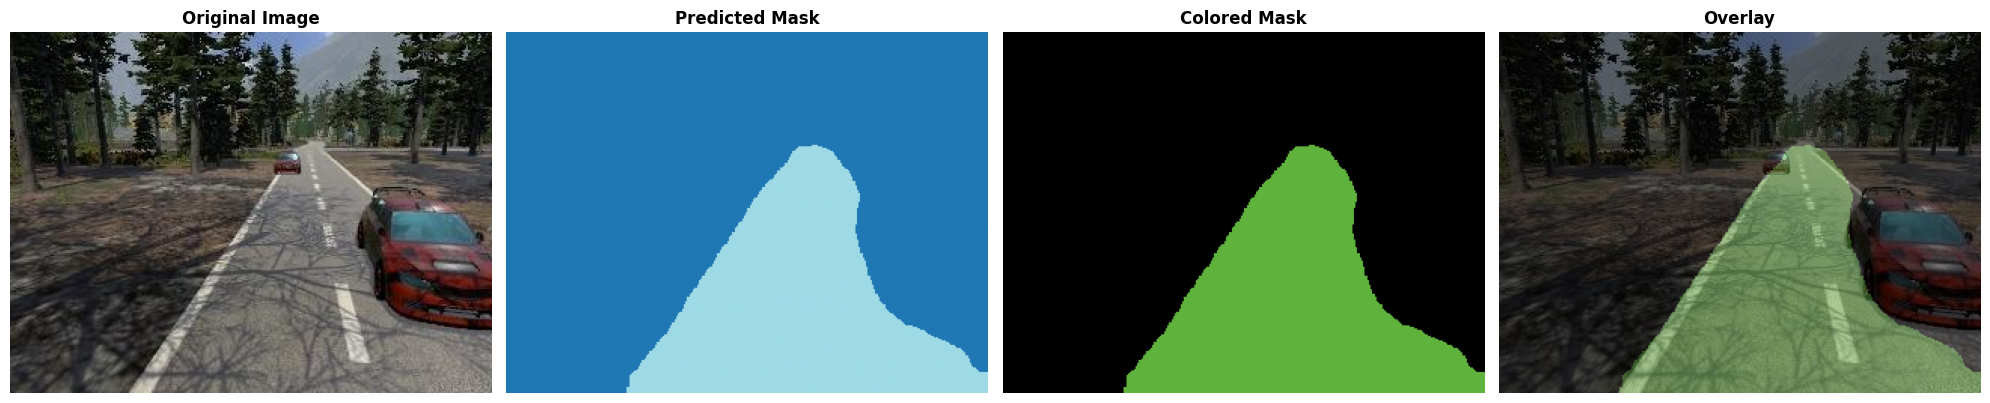

  Detected classes: [0 1]
    Class 0: 56935 pixels (74.13%)
    Class 1: 19865 pixels (25.87%)


In [14]:
# Step 4: Test the fine-tuned model
print("\nStep 5: Testing fine-tuned model on test images...")
print("="*60)
test_finetuned_model(trained_model, 'Semantic Seg Dataset/test/images', num_samples=5, num_classes=2)